#### **Exploratory Data Analysis**

**Import**

In [1]:
import sys
import os
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

**Set the project path**

In [14]:
base_dir = os.path.dirname(os.getcwd())
sys.path.append(base_dir)
print(f"base_dir = {base_dir}")

data_dir = os.path.join(base_dir, 'data', 'processed_data')
print(f"data_dir = {data_dir}")

print(f"The files in data_dir: {os.listdir(data_dir)}")

base_dir = d:\Document\2025.2\IT3191E_Machine_Learning\ML_FinalProject_NILM_REFIT
data_dir = d:\Document\2025.2\IT3191E_Machine_Learning\ML_FinalProject_NILM_REFIT\data\processed_data
The files in data_dir: ['House2_full.csv', 'House2_part1.csv', 'House2_part2.csv', 'House2_part3.csv', 'House2_part4.csv', 'House2_part5.csv']


**Combine 5 CSV files into one `DataFrame`**

In [15]:
print("Reading data...")
dfs = []
for i in range(1, 6):  # i = 1, 2, 3, 4, 5
    filepath = os.path.join(data_dir, f'House2_part{i}.csv')
    print(f"  Reading House2_part{i}.csv...")
    df_part = pd.read_csv(filepath)
    dfs.append(df_part)

df = pd.concat(dfs, axis=0, ignore_index=True)
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")
print(f"Column names: {df.columns.tolist()}")

Reading data...
  Reading House2_part1.csv...
  Reading House2_part2.csv...
  Reading House2_part3.csv...
  Reading House2_part4.csv...
  Reading House2_part5.csv...
Number of rows: 5,733,526
Number of columns: 12
Column names: ['Time', 'Unix', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']


**Save the merged df to a `.csv` file**

In [16]:
full_path = os.path.join(data_dir, 'House2_full.csv')

if not os.path.exists(full_path):
    print("Saving House2_full.csv...")
    df.to_csv(full_path, index=False)
    print(f"Saved at: {full_path}")
else:
    print(f"The file already exists")
    print("Reloading from House2_full.csv...")
    df = pd.read_csv(full_path)
    print(f"Loaded: {len(df):,} rows")


The file already exists
Reloading from House2_full.csv...
Loaded: 5,733,526 rows


**View basic information**

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5733526 entries, 0 to 5733525
Data columns (total 12 columns):
 #   Column      Dtype
---  ------      -----
 0   Time        str  
 1   Unix        int64
 2   Aggregate   int64
 3   Appliance1  int64
 4   Appliance2  int64
 5   Appliance3  int64
 6   Appliance4  int64
 7   Appliance5  int64
 8   Appliance6  int64
 9   Appliance7  int64
 10  Appliance8  int64
 11  Appliance9  int64
dtypes: int64(11), str(1)
memory usage: 524.9 MB


**See the first few lines**

In [18]:
df.head(5)

,Time,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
0,2013-09-17 22:08:11,1379455691,695,88,0,0,0,0,0,0,0,0
1,2013-09-17 22:08:18,1379455698,694,88,0,0,0,0,0,0,0,0
2,2013-09-17 22:08:26,1379455706,694,88,0,0,0,0,0,0,0,0
3,2013-09-17 22:08:34,1379455714,702,88,0,0,0,0,0,0,0,0
4,2013-09-17 22:08:42,1379455722,700,88,0,0,0,0,0,0,0,0


**Descriptive statistics**

In [19]:
df.describe()

,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
count,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06
mean,1.409809e+09,4.651023e+02,3.576811e+01,1.826877e+01,6.154452e+01,3.965859e+00,3.277610e+00,1.549044e+00,1.733205e+00,2.315502e+01,3.689970e-01
std,1.401948e+07,1.062579e+03,4.565278e+01,1.743028e+02,3.523295e+02,1.338795e+01,5.863865e+01,3.799969e+01,5.694687e+00,2.494471e+02,5.368747e+00
min,1.379456e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.399690e+09,1.080000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.410659e+09,1.680000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.421611e+09,3.310000e+02,8.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.432800e+09,2.459500e+04,1.690000e+03,3.584000e+03,3.092000e+03,3.584000e+03,3.072000e+03,3.968000e+03,3.040000e+03,3.729000e+03,2.048000e+03


**Check missing value**

In [20]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print("NaNs/column:")
result = pd.DataFrame({
    'NaNs': missing,
    'Percentage (%)': missing_pct
})
print(result[result['NaNs'] > 0])

if missing.sum() == 0:
    print("No missing values")


NaNs/column:
Empty DataFrame
Columns: [NaNs, Percentage (%)]
Index: []
No missing values


**Process the `Time` column**

In [21]:
df['Time'] = pd.to_datetime(df['Time'])

print(f"Time data type: {df['Time'].dtype}") 
print(f"Start time: {df['Time'].min()}")
print(f"End time: {df['Time'].max()}")
print(f"Time interval: {df['Time'].max() - df['Time'].min()}")

time_diff = df['Time'].diff().dropna()
print(f"Mean distance between samples: {time_diff.mean()}")
print(f"Most common distance: {time_diff.mode()[0]}")

Time data type: datetime64[us]
Start time: 2013-09-17 22:08:11
End time: 2015-05-28 08:05:43
Time interval: 617 days 09:57:32
Mean distance between samples: 0 days 00:00:09.303988
Most common distance: 0 days 00:00:07


**Calculate `Appliance_Others`**

In [22]:
appliance_cols = ['Appliance1', 'Appliance2', 'Appliance3', 
                  'Appliance4', 'Appliance5', 'Appliance6',
                  'Appliance7', 'Appliance8', 'Appliance9']

df['sum_9_appliances'] = df[appliance_cols].sum(axis=1)

df['Appliance_Others'] = df['Aggregate'] - df['sum_9_appliances']

negative_count = (df['Appliance_Others'] < 0).sum()
print(f"Number of rows with Appliance_Others < 0 (to be deleted): {negative_count:,}")

df = df[df['Appliance_Others'] >= 0].copy()
print(f"The {negative_count:,} line has been removed. The current minimum value is: {df['Appliance_Others'].min()}")

df.drop(columns=['sum_9_appliances'], inplace=True)

print(f"Appliance_Others summarizes:")
print(df['Appliance_Others'].describe())

Number of rows with Appliance_Others < 0 (to be deleted): 28,444
The 28,444 line has been removed. The current minimum value is: 0
Appliance_Others summarizes:
count    5.705082e+06
mean     3.214029e+02
std      9.227989e+02
min      0.000000e+00
25%      8.300000e+01
50%      1.120000e+02
75%      2.300000e+02
max      2.438700e+04
Name: Appliance_Others, dtype: float64


**Draw the `aggregate` over time (first 3 days)**

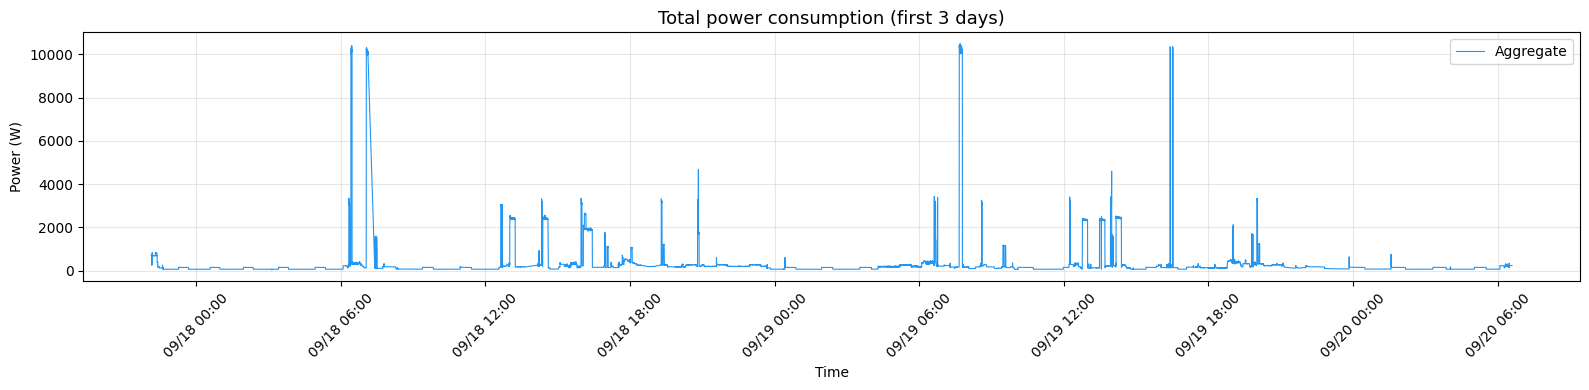

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sample_3days = df.head(3 * 24 * 450)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(sample_3days['Time'], sample_3days['Aggregate'], 
        color='#2196F3', linewidth=0.8, label='Aggregate')
ax.set_title('Total power consumption (first 3 days)', fontsize=13)
ax.set_xlabel('Time')
ax.set_ylabel('Power (W)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


**Draw the on/off pattern for each device**

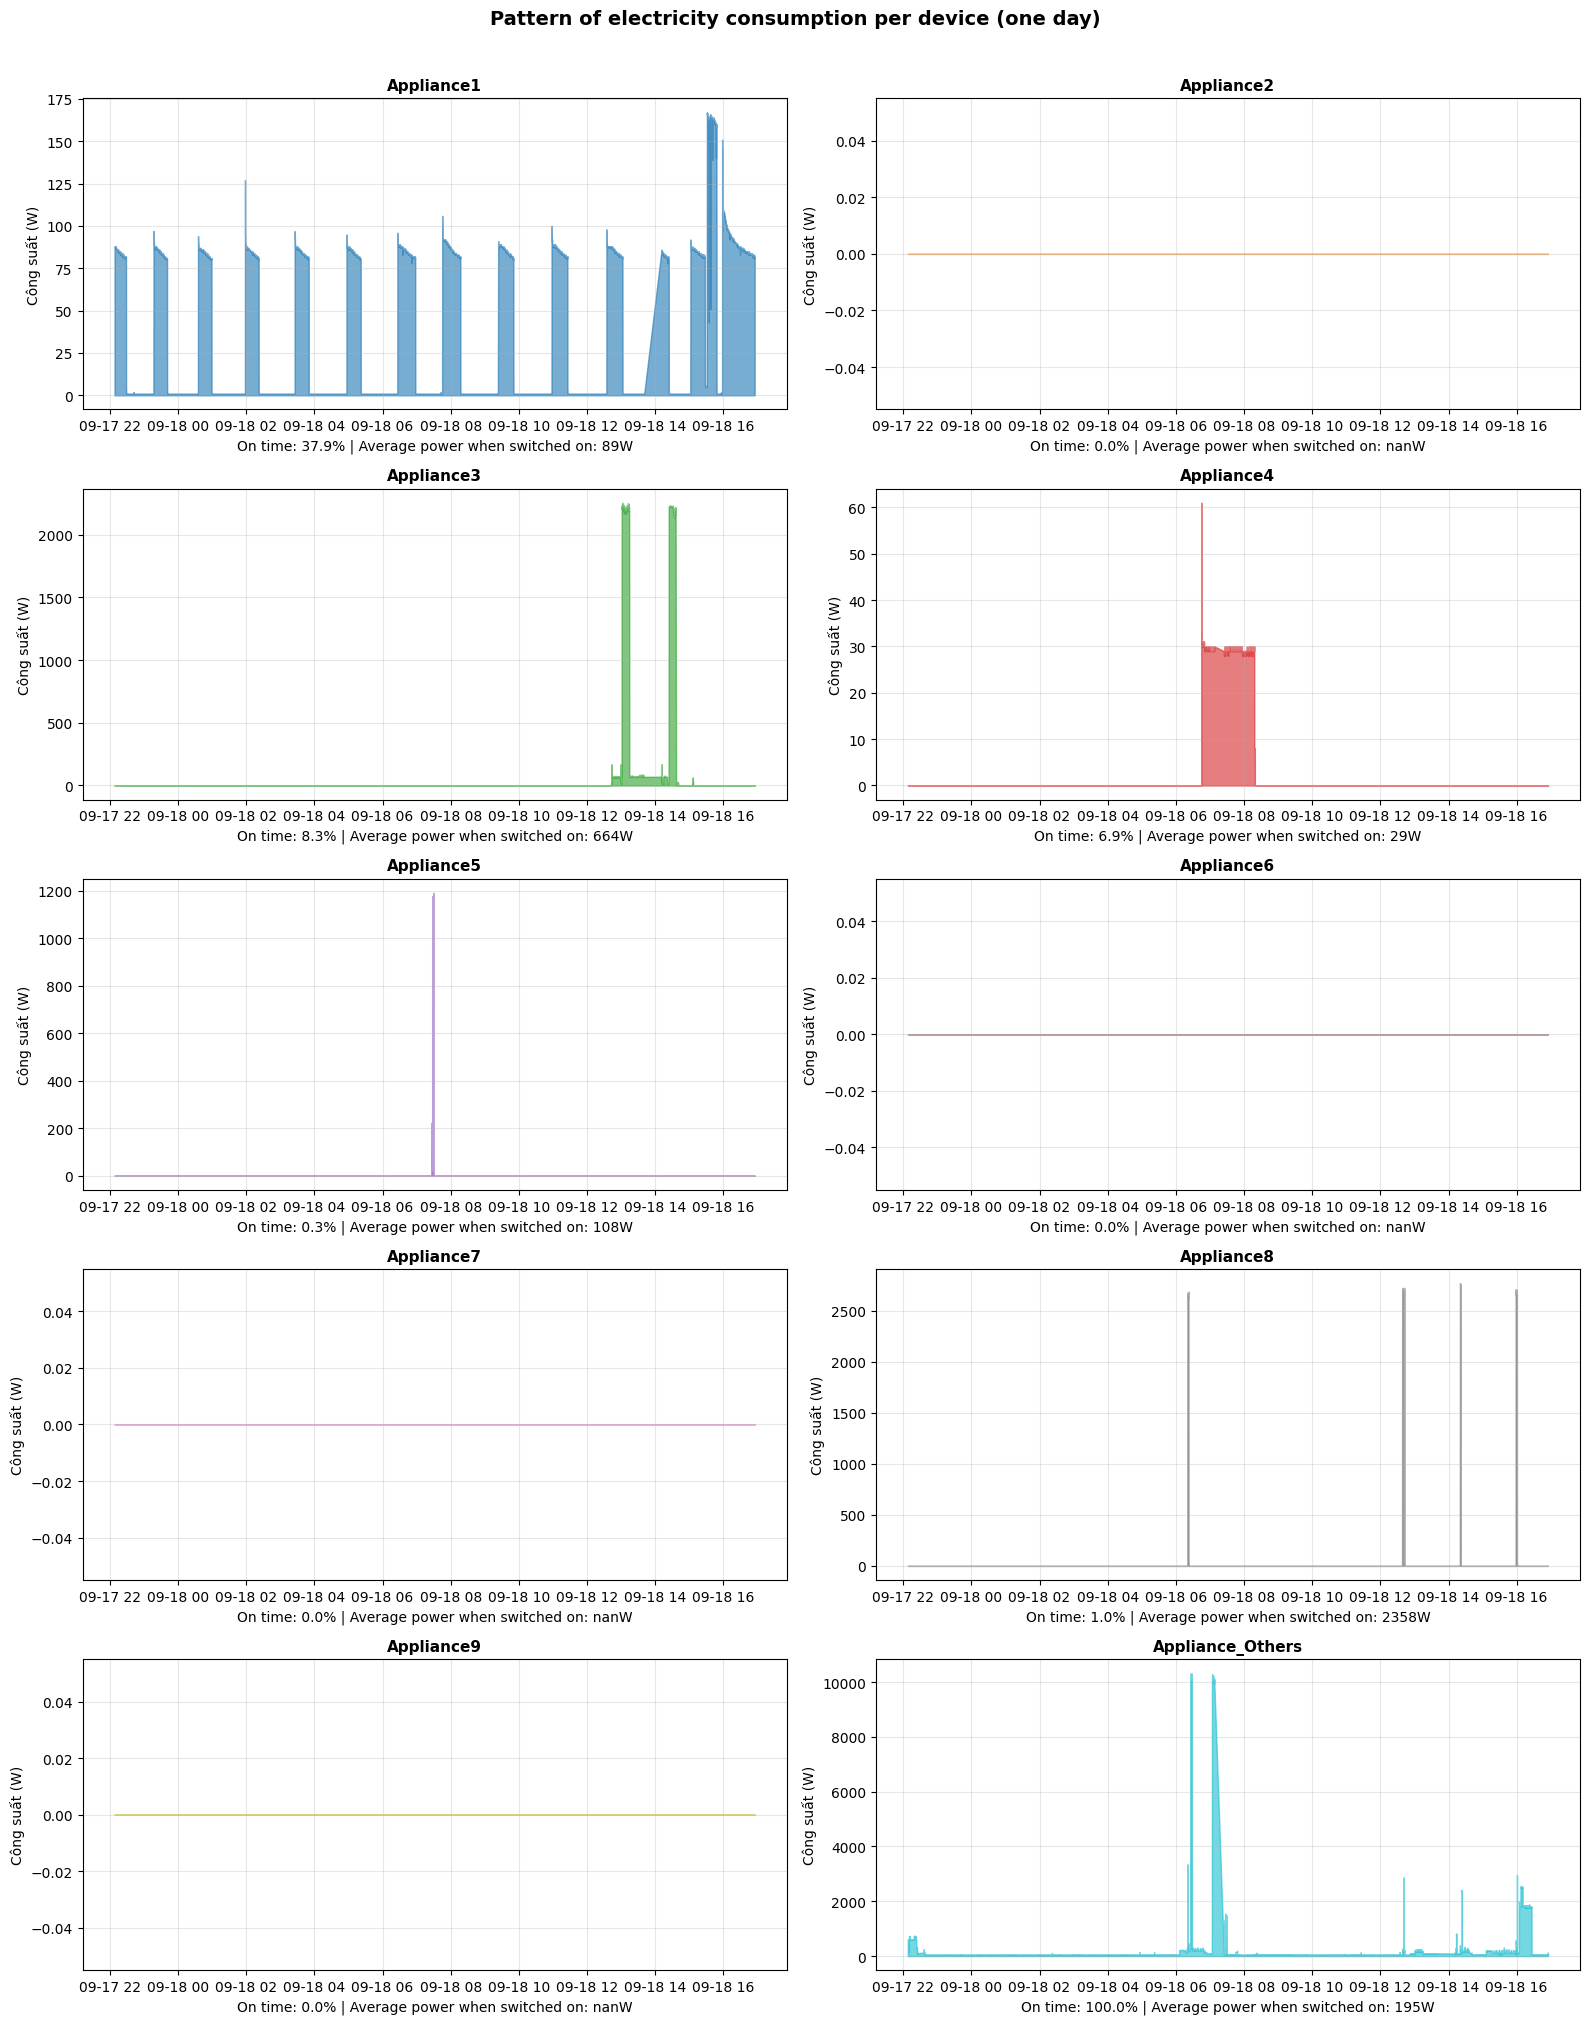

In [25]:
all_target_cols = appliance_cols + ['Appliance_Others']

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

sample_1day = df.head(24 * 450)

for i, col in enumerate(all_target_cols):
    ax = axes[i]
    ax.fill_between(sample_1day['Time'], sample_1day[col], 
                    alpha=0.6, color=f'C{i}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Công suất (W)')
    ax.grid(True, alpha=0.3)
    
    on_pct = (sample_1day[col] > 10).mean() * 100
    avg_power = sample_1day[col][sample_1day[col] > 10].mean()
    ax.set_xlabel(f'On time: {on_pct:.1f}% | '
                  f'Average power when switched on: {avg_power:.0f}W')

plt.suptitle('Pattern of electricity consumption per device (one day)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Statistics for each device**

In [43]:
print(f"{'Appliance':<20} {'% on':>8} {'Average power when switched on':>35} {'Max':>10}")
print("-" * 76)

for col in all_target_cols:
    is_on = df[col] > 10 
    pct_on = is_on.mean() * 100
    avg_on = df[col][is_on].mean() if is_on.any() else 0
    max_val = df[col].max()
    print(f"{col:<20} {pct_on:>7.1f}% {avg_on:>34.1f}W {max_val:>9.1f}W")

Appliance                % on      Average power when switched on        Max
----------------------------------------------------------------------------
Appliance1              39.7%                               87.9W    1639.0W
Appliance2               4.0%                              440.4W    2555.0W
Appliance3               7.7%                              772.9W    2480.0W
Appliance4               9.1%                               43.2W     512.0W
Appliance5               0.7%                              393.2W    1251.0W
Appliance6               0.2%                              636.6W    1024.0W
Appliance7              10.8%                               16.1W    1536.0W
Appliance8               0.9%                             2250.3W    2939.0W
Appliance9               0.6%                               60.0W     384.0W
Appliance_Others        99.9%                              321.6W   24387.0W
